# CO on a CuPd nanoparticle: relaxed energies + batched replica exchange

The production-style molecular GCMC workflow (**requires a GPU** and the MACE/nvalchemi stack):

1. a CuPd nanoparticle in a spherical insertion shell,
2. rigid CO insertion/deletion at $\mu_\mathrm{CO} = E_\mathrm{MACE}(\mathrm{CO}) + \Delta\mu$, plus Cu↔Pd permutations so the alloy can segregate under the adsorbate,
3. one replica per $\Delta\mu$, all replicas relaxed **in one batched pass per MC step** on a single GPU (`BatchedReplicaExchange` + `AlchemiFCalculator`),
4. coverage vs $\Delta\mu$ = the adsorption phase diagram, plus structure snapshots.

This notebook runs a deliberately tiny demo (38-atom particle, 3 replicas, few steps).
The committed script `examples/re_gcmc_co_cupd_batched.py` is the full version (size, ladder, convergence check all configurable).

In [1]:
import os
import warnings

# Upstream noise, not mcpy's: torch deprecating torch.jit.load (mace still
# uses it) and a benign tensor-construction warning inside mace itself.
# Filtered narrowly here so the teaching output stays readable; do NOT
# suppress these globally in a library.
warnings.filterwarnings('ignore', category=DeprecationWarning,
                        module=r'torch\.jit.*')
warnings.filterwarnings('ignore', category=UserWarning,
                        module=r'mace\.modules.*')
import numpy as np
import matplotlib.pyplot as plt

from mcpy.utils.logging import configure as configure_logging
configure_logging()

from ase.build import molecule
from ase.cluster import Octahedron
from mcpy.moves import (MoleculeInsertionMove, MoleculeDeletionMove,
                        PermutationMove, MoveSelector)
from mcpy.ensembles.grand_canonical_ensemble import GrandCanonicalEnsemble
from mcpy.ensembles import BatchedReplicaExchange
from mcpy.calculators import AlchemiFCalculator
from mcpy.cell import SphericalCell

import shutil

outdir = os.path.expanduser('~/mcpy_tmp_runs/co_cupd_notebook')
# Fresh directory per execution: the trajectory writer appends, so
# re-running the notebook into a stale dir would interleave frames.
shutil.rmtree(outdir, ignore_errors=True)
os.makedirs(outdir)

import logging
# The phase-diagram style asks for Arial; systems without it fall back
# to DejaVu with one warning per glyph lookup - silence the spam.
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_script.py:365: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
# Cu33Pd5 truncated octahedron ('small Pd quantity')
rng = np.random.default_rng(7)
np_atoms = Octahedron('Cu', 4, cutoff=1)
sym = np.array(np_atoms.get_chemical_symbols())
sym[rng.choice(len(np_atoms), size=5, replace=False)] = 'Pd'
np_atoms.set_chemical_symbols(sym.tolist())
np_atoms.center(vacuum=10.0)
np_atoms.pbc = False
n_metal = len(np_atoms)
np_atoms.get_chemical_formula()

'Cu33Pd5'

In [3]:
co = molecule('CO')
calc = AlchemiFCalculator(checkpoint='medium-mpa-0', steps=30, fmax=0.1,
                          compile_model=False)   # compile on for production
e_co = calc.get_potential_energy(molecule('CO', cell=[20.]*3, pbc=False))
print(f'E(CO) = {e_co:.3f} eV')

/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument


/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/mace/modules/models.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "atomic_numbers", torch.tensor(atomic_numbers, dtype=torch.int64)


E(CO) = -14.288 eV


In [4]:
delta_mus = [-1.6, -1.4, -1.2, -1.0]        # coarse 4-point ladder for the demo
T = 400.0
mus = [{'CO': e_co + d} for d in delta_mus]

def gcmc_factory(mu, rank):
    atoms = np_atoms.copy()
    cell = SphericalCell(atoms, vacuum=3.5,
                         species_radii={'Cu': 2.4, 'Pd': 2.5, 'C': 0., 'O': 0.},
                         seed=100 + rank)
    ms = MoveSelector([2, 2, 1],
                      [MoleculeInsertionMove(cell, co, 'CO', seed=10 + rank, min_insert=1.3),
                       MoleculeDeletionMove(cell, co, 'CO', seed=40 + rank),
                       PermutationMove(species=['Cu', 'Pd'], seed=70 + rank)],
                      n_moves=3)
    d = delta_mus[rank]
    return GrandCanonicalEnsemble(
        atoms=atoms, cells=[cell], calculator=calc, mu=mu, units_type='metal',
        species=['Cu', 'Pd'], molecules={'CO': co}, temperature=T,
        move_selector=ms, random_seed=rank,
        outfile=os.path.join(outdir, f'gcmc_dmu_{d}.out'),
        traj_file=os.path.join(outdir, f'gcmc_dmu_{d}.xyz'),
        outfile_write_interval=1, trajectory_write_interval=1)

pt = BatchedReplicaExchange(gcmc_factory, calculator=calc, mus=mus,
                            gcmc_steps=150, exchange_interval=5,
                            write_out_interval=15, seed=1,
                            outfile=os.path.join(outdir, 're.log'),
                            global_minimum_file=os.path.join(outdir, 'gm.xyz'))
pt.run()   # ~5-10 min on a modern GPU

2026-07-08 11:28:52,315 mcpy.ensembles.batched_replica_exchange INFO: RE 0/150 | N:   38   38   38   38 | E(eV):    -133.04    -133.04    -133.04    -133.04 | swap acc n/a


W0708 11:28:52.946000 273194 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8] torch._dynamo hit config.recompile_limit (8)
W0708 11:28:52.946000 273194 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8]    function: '_rebuild' (/home/energystorage/miniconda3/envs/alchemi/lib/python3.12/site-packages/nvalchemi/hooks/neighbor_list.py:220)
W0708 11:28:52.946000 273194 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8]    last reason: 1/7: batch._storage.groups['atoms']._data._batch_size[0] == self._neighbor_matrix.size()[0]  # if self._neighbor_matrix is None or self._neighbor_matrix.shape[0] != N:  # nvalchemi/hooks/neighbor_list.py:237 in _rebuild (_dynamo/variables/tensor.py:2242 in evaluate_expr)
W0708 11:28:52.946000 273194 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0708 11:28:52.946000 273194 site-packages/torch/_dynamo/convert_frame.py:1853] [1/8] To diagnose recompilation issues, see 

2026-07-08 11:29:14,513 mcpy.ensembles.batched_replica_exchange INFO: RE 15/150 | N:   38   46   42   44 | E(eV):    -133.61    -194.98    -164.45    -180.35 | swap acc 100%


2026-07-08 11:29:36,510 mcpy.ensembles.batched_replica_exchange INFO: RE 30/150 | N:   42   38   44   50 | E(eV):    -164.86    -133.58    -180.42    -226.95 | swap acc 100%


2026-07-08 11:30:00,246 mcpy.ensembles.batched_replica_exchange INFO: RE 45/150 | N:   42   46   40   42 | E(eV):    -165.24    -196.83    -149.33    -165.18 | swap acc 100%


...

2026-07-08 11:32:20,463 mcpy.ensembles.batched_replica_exchange INFO: RE 135/150 | N:   46   56   42   50 | E(eV):    -196.78    -274.44    -165.10    -227.61 | swap acc 100%


2026-07-08 11:32:39,492 mcpy.ensembles.batched_replica_exchange INFO: replica 0 done: steps=150 N=52 E=-243.6879 eV | move acc: 2% 5% 19%


2026-07-08 11:32:39,493 mcpy.ensembles.batched_replica_exchange INFO: replica 1 done: steps=150 N=50 E=-228.1283 eV | move acc: 3% 7% 12%


2026-07-08 11:32:39,494 mcpy.ensembles.batched_replica_exchange INFO: replica 2 done: steps=150 N=48 E=-212.3358 eV | move acc: 10% 6% 20%


2026-07-08 11:32:39,495 mcpy.ensembles.batched_replica_exchange INFO: replica 3 done: steps=150 N=44 E=-180.6618 eV | move acc: 19% 4% 19%


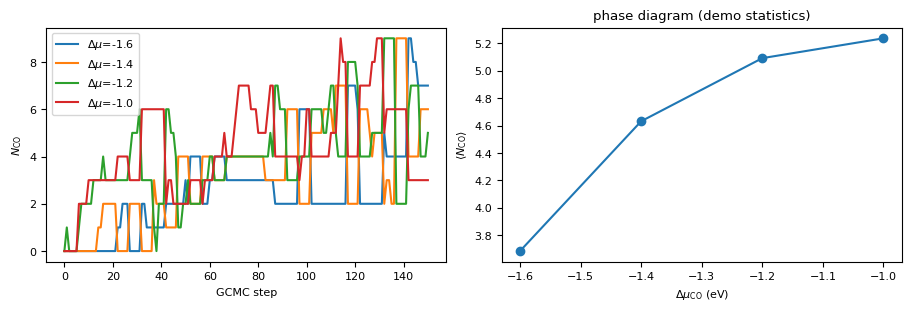

In [5]:
def coverage(d):
    ns = []
    with open(os.path.join(outdir, f'gcmc_dmu_{d}.out')) as f:
        for line in f:
            s = line.split()
            if s and s[0].isdigit():
                ns.append((int(s[1]) - n_metal) / 2)
    return ns

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)
for d in delta_mus:
    a1.plot(coverage(d), label=f'$\\Delta\\mu$={d}')
a1.set(xlabel='GCMC step', ylabel=r'$N_\mathrm{CO}$'); a1.legend()
cov = [np.mean(coverage(d)[len(coverage(d))//2:]) for d in delta_mus]
a2.plot(delta_mus, cov, 'o-')
a2.set(xlabel=r'$\Delta\mu_\mathrm{CO}$ (eV)', ylabel=r'$\langle N_\mathrm{CO}\rangle$',
       title='phase diagram (demo statistics)')
plt.show()

## The phase diagram

The coverage curve above is an *isotherm* (sampling-side view). The thermodynamic
object is the **phase diagram**: for each CO stoichiometry the library takes the
lowest-energy structure seen anywhere in the run, plots its grand-canonical free
energy $\Delta G(\Delta\mu) = E(N) - E_\mathrm{ref} - N(\mu_\mathrm{ref}+\Delta\mu)$
per metal atom, and extracts the stable envelope, the phase transitions, a
pressure twin-axis, and per-phase structure thumbnails.

CO is counted through its single carbon (`adsorbate='C'`), labelled properly via
`adsorbate_label='CO'`, and `atoms_per_reservoir_molecule=1` selects the molecular
pressure convention (the default 2 is for dissociative X$_2$ reservoirs like
O/O$_2$). With this short demo run the envelope is crude; pool more trajectories
for production diagrams.

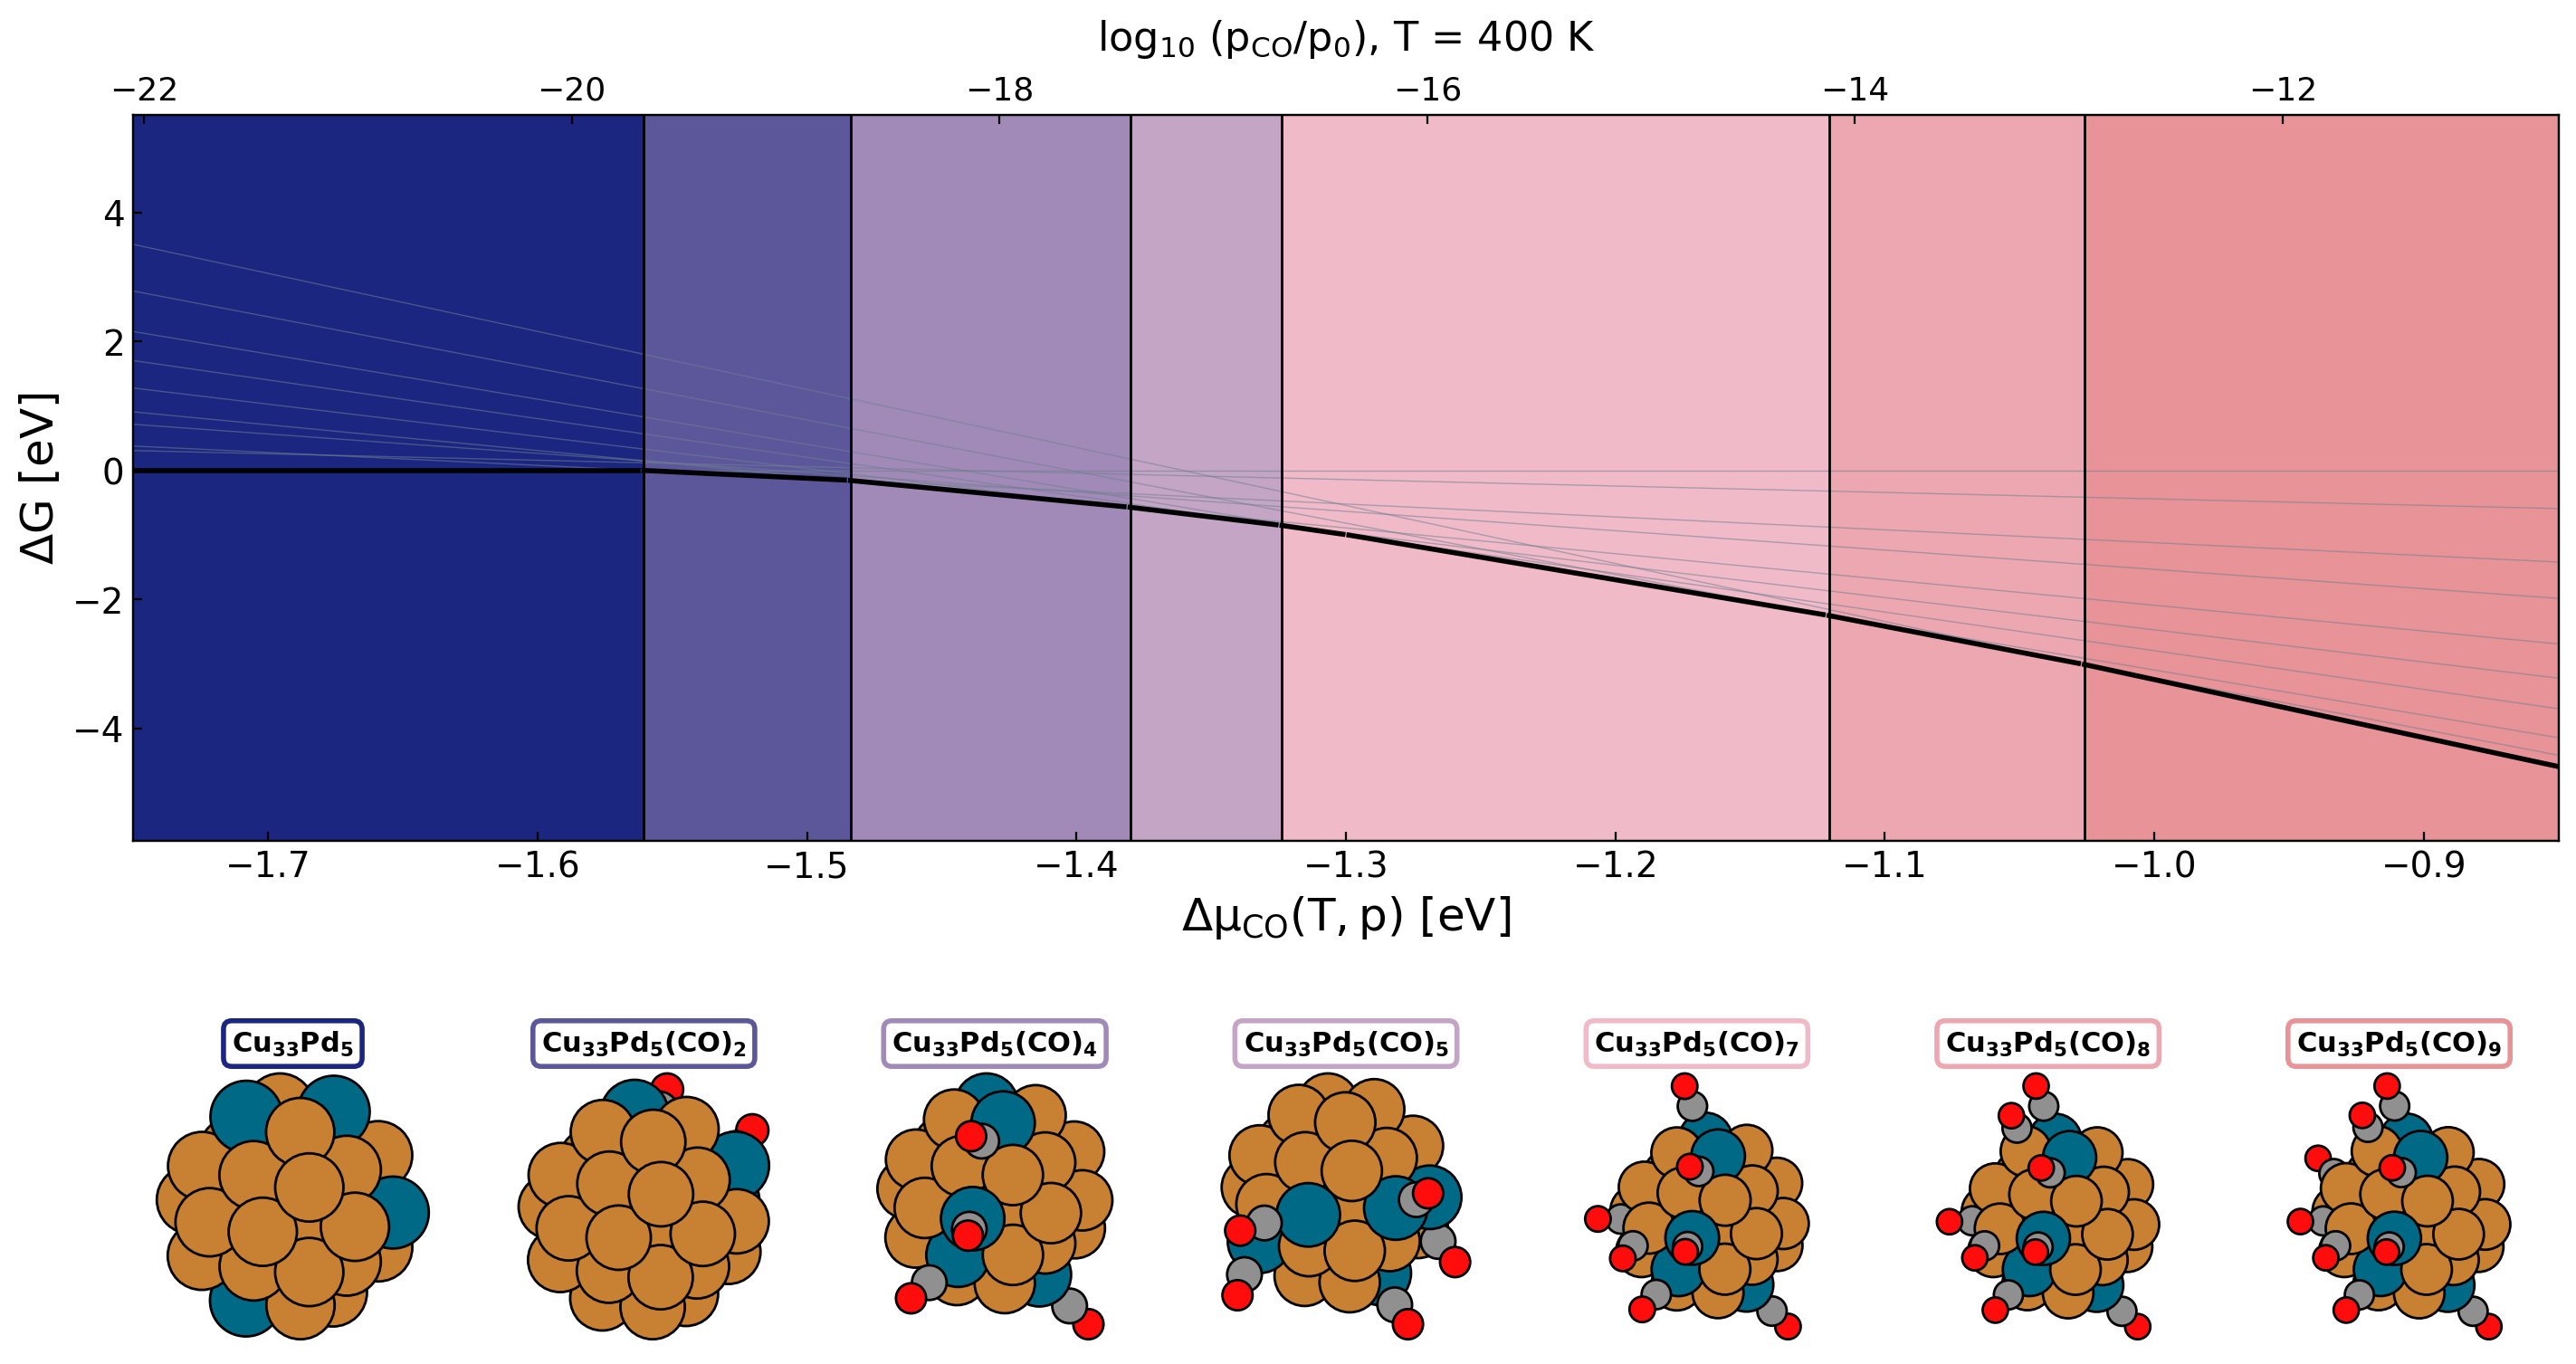

stable CO stoichiometries: [0, 2, 4, 5, 7, 8, 9]
transitions at delta_mu: [np.float64(-1.561), np.float64(-1.484), np.float64(-1.38), np.float64(-1.324), np.float64(-1.121), np.float64(-1.026)]


In [6]:
import ase.io
from mcpy.utils.phase_diagram import plot_phase_diagram

frames = [ase.io.read(os.path.join(outdir, f'gcmc_dmu_{d}.xyz'), index=':')
          for d in delta_mus]

res = plot_phase_diagram(
    frames,
    adsorbate='C', adsorbate_label='CO',
    atoms_per_reservoir_molecule=1,
    metal_symbols=('Cu', 'Pd'),
    mu_ref=e_co, kind='nano', T=T,
    dmu_range=(min(delta_mus) - 0.15, max(delta_mus) + 0.15),
    rotation='12z,-75x', gamma_in_ev=True,
    show_plot=True)

print('stable CO stoichiometries:', [res['stoich'][i] for i in res['phase_order']])
print('transitions at delta_mu:', [round(t, 3) for t in res['transitions']])

**Reading the result**: coverage rises with $\Delta\mu$; at low coverage CO decorates the Pd sites first (stronger binding), which together with the Cu↔Pd permutation move drives Pd toward CO-covered surface positions.

**Production settings** (see `examples/re_gcmc_co_cupd_batched.py`):
a denser $\Delta\mu$ ladder in the rising part of the isotherm (avoid the saturated plateau, it carries no information), hundreds of GCMC steps with the built-in stationarity check, `--octa-length 9 --octa-cutoff 3` for a 405-atom particle, and `compile_model=True` for ~2x faster forwards.
The sampler and potential behind all of this are cross-validated against LAMMPS: `benchmark/README.md`.